<a href="https://colab.research.google.com/github/Erilocshada/erilocshada-PCVK-2026-course/blob/main/Praktikum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import pandas as pd
import cv2 as cv
from PIL import Image
from skimage import io
from skimage import transform
import matplotlib.pyplot as plt

urls = [
    "https://iiif.lib.ncsu.edu/iiif/0052574/full/800,/0/default.jpg",
    "https://iiif.lib.ncsu.edu/iiif/0016007/full/800,/0/default.jpg",
    "https://placekitten.com/800/571"
]

print("Jumlah gambar:", len(urls))

Jumlah gambar: 3


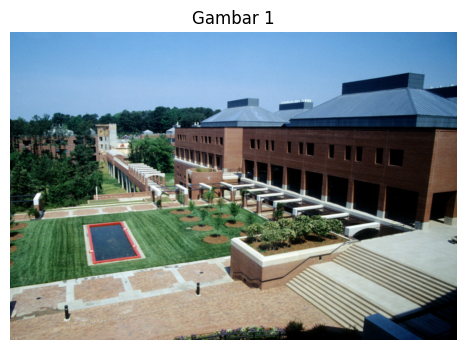

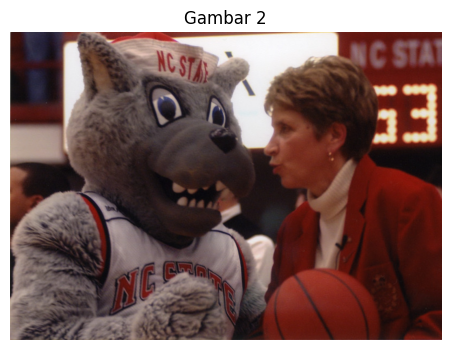

Gagal membaca gambar 3
Error: 521 Server Error: <none> for url: https://placekitten.com/800/571


In [7]:
import requests
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt

for i, url in enumerate(urls):
    try:
        response = requests.get(url, timeout=15)
        response.raise_for_status()

        image = Image.open(BytesIO(response.content)).convert("RGB")

        plt.figure(figsize=(6, 4))
        plt.imshow(image)
        plt.axis("off")
        plt.title(f"Gambar {i+1}")

        plt.show()

    except Exception as e:
        print(f"Gagal membaca gambar {i+1}")
        print("Error:", e)

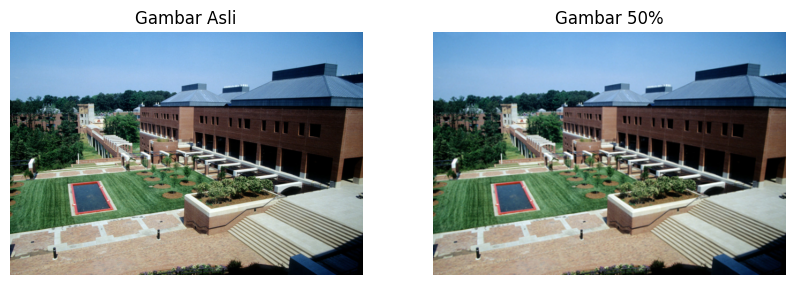

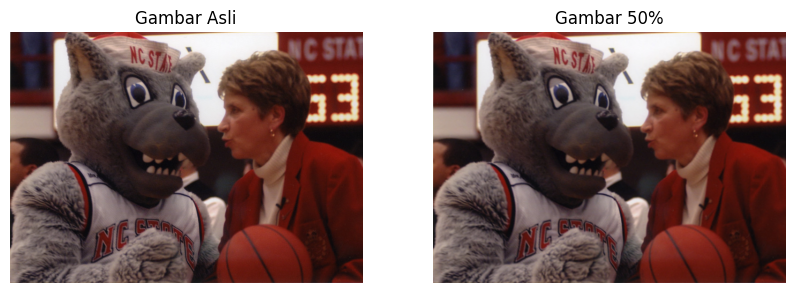

Gagal memproses gambar 3: 521 Server Error: <none> for url: https://placekitten.com/800/571


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

for i, url in enumerate(urls):
    try:
        response = requests.get(url, timeout=15)
        response.raise_for_status()

        image = Image.open(BytesIO(response.content)).convert("RGB")

        width, height = image.size

        new_width = width // 2
        new_height = height // 2

        resized_image = image.resize((new_width, new_height))

        plt.figure(figsize=(10, 4))

        plt.subplot(1, 2, 1)
        plt.imshow(image)
        plt.title("Gambar Asli")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(resized_image)
        plt.title("Gambar 50%")
        plt.axis("off")

        plt.show()

    except Exception as e:
        print(f"Gagal memproses gambar {i+1}: {e}")

In [9]:
image_np = np.array(image)

print("Dimensi array :", image_np.ndim)
print("Shape         :", image_np.shape)
print("Jumlah pixel  :", image_np.size)
print("Tipe data     :", image_np.dtype)
print("Ukuran elemen :", image_np.itemsize, "byte")

Dimensi array : 3
Shape         : (571, 800, 3)
Jumlah pixel  : 1370400
Tipe data     : uint8
Ukuran elemen : 1 byte


In [10]:
# Mengambil pixel pada koordinat tertentu
x = 100
y = 100

pixel = image_np[y, x]

print("Nilai pixel:", pixel)

Nilai pixel: [202 179 148]


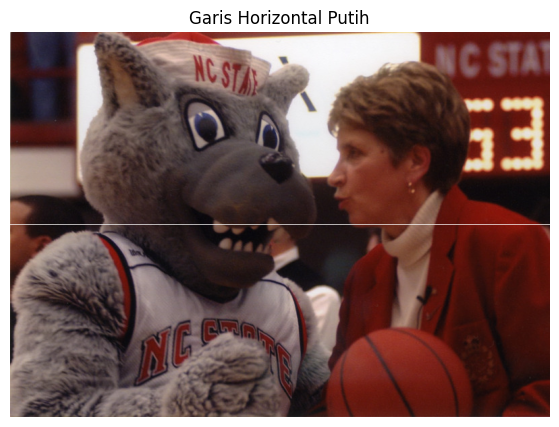

In [11]:
image_garis = image_np.copy()

height, width, channels = image_garis.shape

y_tengah = height // 2

image_garis[y_tengah, :, :] = [255, 255, 255]

plt.figure(figsize=(8, 5))
plt.imshow(image_garis)
plt.title("Garis Horizontal Putih")
plt.axis("off")
plt.show()